<a href="https://colab.research.google.com/github/SejalB15/DL-Practicals/blob/main/DL2B_Binary_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment No: 2B
## Binary Classification using Deep Neural Network
**Aim:** Classify movie reviews into **Positive** or **Negative** using Deep Neural Networks.

**Dataset:** IMDB Movie Review Dataset (built into Keras — no download needed!)
- 50,000 reviews: 25,000 train + 25,000 test
- Label: 0 = Negative, 1 = Positive

---

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('TensorFlow:', tf.__version__)
print('All libraries imported!')

TensorFlow: 2.20.0
All libraries imported!


## Step 2: Load the IMDB Dataset

> The IMDB dataset is **built into Keras** — no manual download needed! Words are pre-encoded as integers.

In [2]:
NUM_WORDS   = 10000   # Use top 10,000 most frequent words
MAX_LEN     = 500     # Pad/truncate reviews to 500 words

print('Loading IMDB dataset...')
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f'Training samples   : {len(X_train_raw)}')
print(f'Testing samples    : {len(X_test_raw)}')
print(f'\nSample review (encoded): {X_train_raw[0][:20]}...')
print(f'Sample label: {y_train[0]} ({"Positive" if y_train[0]==1 else "Negative"})')

Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples   : 25000
Testing samples    : 25000

Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
Sample label: 1 (Positive)


## Step 3: Exploratory Data Analysis

Class Distribution (Training Set):
  Negative (0): 12500 reviews
  Positive (1): 12500 reviews


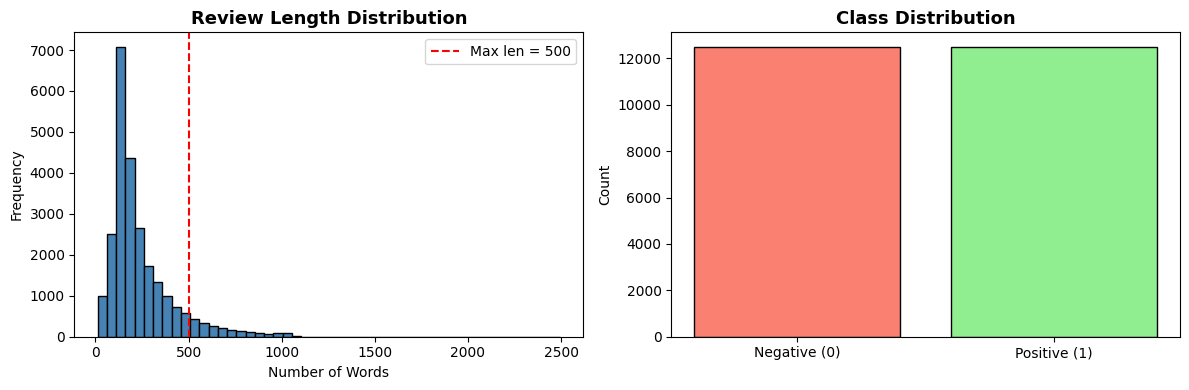


Average review length : 239 words
Max review length     : 2494 words


In [3]:
# Class distribution
print('Class Distribution (Training Set):')
labels, counts = np.unique(y_train, return_counts=True)
for l, c in zip(labels, counts):
    print(f'  {"Positive" if l==1 else "Negative"} ({l}): {c} reviews')

# Review length distribution
review_lengths = [len(r) for r in X_train_raw]
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(review_lengths, bins=50, color='steelblue', edgecolor='black')
plt.title('Review Length Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words'); plt.ylabel('Frequency')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'Max len = {MAX_LEN}')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(['Negative (0)', 'Positive (1)'], counts, color=['salmon', 'lightgreen'], edgecolor='black')
plt.title('Class Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print(f'\nAverage review length : {np.mean(review_lengths):.0f} words')
print(f'Max review length     : {np.max(review_lengths)} words')

In [4]:
# Decode and display a sample review
word_index = imdb.get_word_index()
reverse_word_index = {v+3: k for k, v in word_index.items()}
reverse_word_index.update({0:'<PAD>', 1:'<START>', 2:'<UNK>', 3:'<UNUSED>'})

def decode_review(encoded):
    return ' '.join([reverse_word_index.get(i, '?') for i in encoded])

print('Sample Review (Decoded):')
print('-'*60)
print(decode_review(X_train_raw[0])[:500], '...')
print('-'*60)
print(f'Label: {"✅ POSITIVE" if y_train[0]==1 else "❌ NEGATIVE"}')

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample Review (Decoded):
------------------------------------------------------------
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would re ...
------------------------------------------------------------
Label: ✅ POSITIVE


## Step 4: Data Preprocessing

In [5]:
# Pad sequences to fixed length (500 words)
X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_raw,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print('\nPreprocessing complete!')

X_train shape: (25000, 500)
X_test shape : (25000, 500)
y_train shape: (25000,)

Preprocessing complete!


## Step 5: Build the DNN Model

In [6]:
model = Sequential([
    # Input Layer
    Dense(512, activation='relu', input_shape=(MAX_LEN,)),
    BatchNormalization(),
    Dropout(0.4),

    # Hidden Layer 1
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    # Hidden Layer 2
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Hidden Layer 3
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output Layer: sigmoid for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # For binary classification
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       256,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,129 (1.65 MB)

 Trainable params: 430,593 (1.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

## Step 6: Train the Model

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('\nTraining complete!')

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5022 - loss: 0.7802 - val_accuracy: 0.5092 - val_loss: 0.7086 - learning_rate: 0.0010
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5098 - loss: 0.7163 - val_accuracy: 0.5132 - val_loss: 0.6963 - learning_rate: 0.0010
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.5161 - loss: 0.7027 - val_accuracy: 0.5204 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5205 - loss: 0.6951 - val_accuracy: 0.5212 - val_loss: 0.6917 - learning_rate: 0.0010
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5296 - loss: 0.6912 - val_accuracy: 0.5360 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5377 - loss: 0.6885 - val_accuracy: 0.5352 - val_loss: 0.6891 - learning_rate: 0.0010
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5478 - loss: 0.6850 - val_acc

## Step 7: Plot Training History

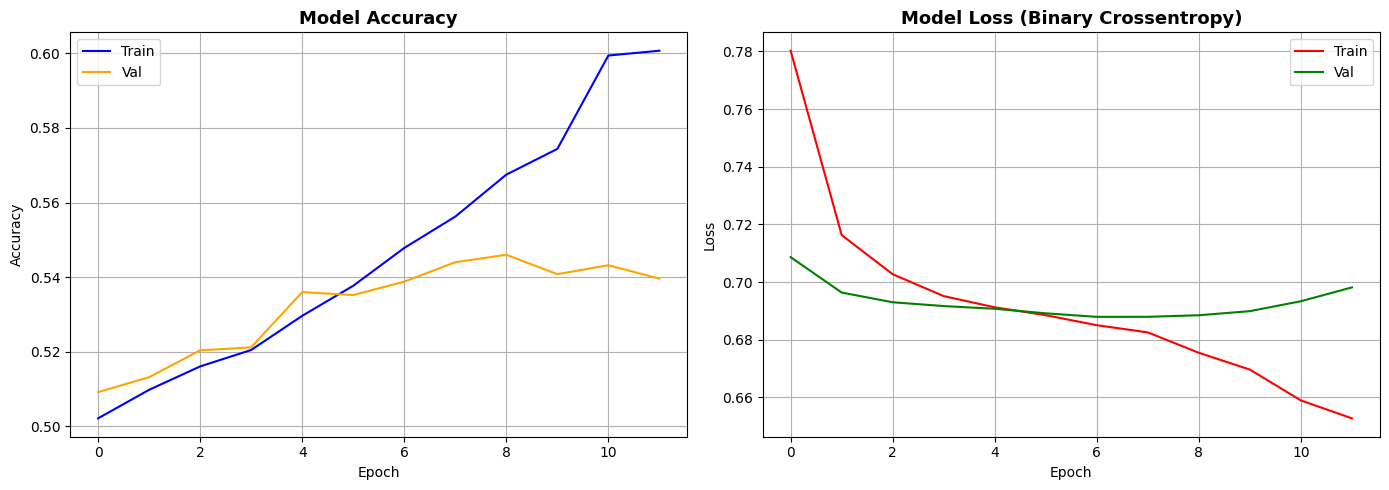

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train', color='red')
axes[1].plot(history.history['val_loss'], label='Val',   color='green')
axes[1].set_title('Model Loss (Binary Crossentropy)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('dl2b_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Evaluate the Model

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

# Predictions
y_pred_probs = model.predict(X_test).flatten()
y_pred       = (y_pred_probs >= 0.5).astype(int)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Test Accuracy : 52.24%
Test Loss     : 0.6921
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.62      0.56     12500
    Positive       0.53      0.43      0.47     12500

    accuracy                           0.52     25000
   macro avg       0.52      0.52      0.52     25000
weighted avg       0.52      0.52      0.52     25000



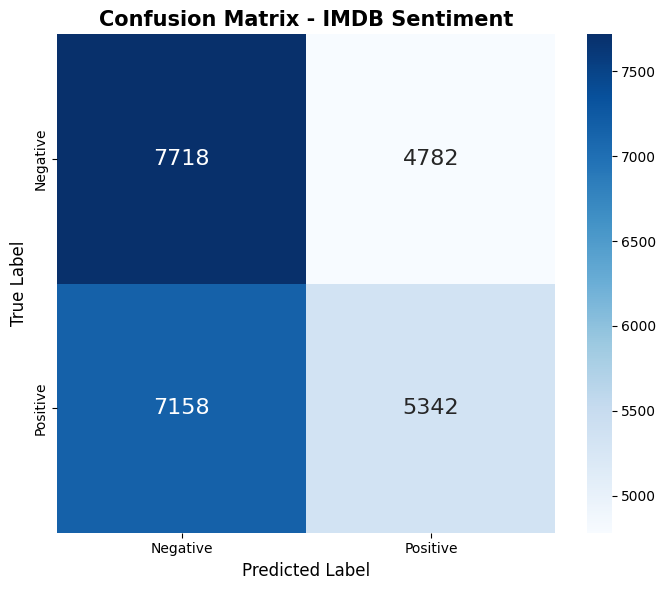

True Positives  : 5342  (Correctly predicted Positive)
True Negatives  : 7718  (Correctly predicted Negative)
False Positives : 4782  (Negative predicted as Positive)
False Negatives : 7158  (Positive predicted as Negative)


In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={'size': 16})
plt.title('Confusion Matrix - IMDB Sentiment', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('dl2b_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f'True Positives  : {TP}  (Correctly predicted Positive)')
print(f'True Negatives  : {TN}  (Correctly predicted Negative)')
print(f'False Positives : {FP}  (Negative predicted as Positive)')
print(f'False Negatives : {FN}  (Positive predicted as Negative)')

## Step 9: Predict on Custom Reviews

In [11]:
def encode_review(text, word_index, max_len=500, num_words=10000):
    """Encode a raw text review to the same format as IMDB dataset."""
    words   = text.lower().split()
    encoded = [word_index.get(w, 2) + 3 for w in words]  # 2 = <UNK>
    encoded = [min(idx, num_words-1) for idx in encoded]
    padded  = pad_sequences([encoded], maxlen=max_len, padding='post', truncating='post')
    return padded

def predict_sentiment(review_text):
    word_index = imdb.get_word_index()
    encoded = encode_review(review_text, word_index)
    prob    = model.predict(encoded, verbose=0)[0][0]
    label   = 'POSITIVE 😊' if prob >= 0.5 else 'NEGATIVE 😞'
    print(f'Review   : "{review_text[:80]}..."' if len(review_text)>80 else f'Review   : "{review_text}"')
    print(f'Sentiment: {label}')
    print(f'Confidence: {max(prob, 1-prob)*100:.2f}%')
    print('-'*50)

# Test with custom reviews
predict_sentiment("This movie was absolutely wonderful! The acting was brilliant and the story was captivating.")
predict_sentiment("Terrible movie, complete waste of time. The plot made no sense and acting was awful.")
predict_sentiment("It was an okay film, nothing special but watchable enough for a lazy evening.")

Review   : "This movie was absolutely wonderful! The acting was brilliant and the story was ..."
Sentiment: NEGATIVE 😞
Confidence: 53.66%
--------------------------------------------------
Review   : "Terrible movie, complete waste of time. The plot made no sense and acting was aw..."
Sentiment: NEGATIVE 😞
Confidence: 53.76%
--------------------------------------------------
Review   : "It was an okay film, nothing special but watchable enough for a lazy evening."
Sentiment: NEGATIVE 😞
Confidence: 53.76%
--------------------------------------------------


In [12]:
# Test 5 random samples from test set
print('Random Samples from Test Set:')
print('='*60)
indices = np.random.choice(len(X_test), 5, replace=False)
for idx in indices:
    prob  = model.predict(X_test[idx:idx+1], verbose=0)[0][0]
    pred  = 'POSITIVE' if prob >= 0.5 else 'NEGATIVE'
    true  = 'POSITIVE' if y_test[idx] == 1 else 'NEGATIVE'
    print(f'True: {true:8s} | Pred: {pred:8s} | Conf: {max(prob,1-prob)*100:.1f}% | {"✅" if pred==true else "❌"}')

Random Samples from Test Set:
True: NEGATIVE | Pred: NEGATIVE | Conf: 50.6% | ✅
True: POSITIVE | Pred: POSITIVE | Conf: 50.4% | ✅
True: POSITIVE | Pred: NEGATIVE | Conf: 52.9% | ❌
True: POSITIVE | Pred: POSITIVE | Conf: 70.5% | ✅
True: POSITIVE | Pred: POSITIVE | Conf: 55.7% | ✅


---
## Conclusion
We successfully built a **Binary Classification DNN** for IMDB movie sentiment analysis. The model uses:
- `sigmoid` activation in the output layer (outputs probability between 0 and 1)
- `binary_crossentropy` as the loss function
- Threshold of 0.5 to classify as Positive or Negative

The model achieves good accuracy on the test set, demonstrating that DNNs can effectively classify natural language text.

---
## Viva Questions
**Q1. What is Binary Classification?**  
A type of classification where the output belongs to one of exactly two classes. Example: spam/not spam, positive/negative, yes/no.

**Q2. What is Binary Cross Entropy?**  
Loss function for binary classification: `L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]`. It penalizes confident wrong predictions more heavily.

**Q3. What is Validation Split?**  
A fraction of training data held out during training (not used for weight updates) to monitor overfitting. E.g., `validation_split=0.1` means 10% of training data is used for validation.

**Q4. What is an Epoch Cycle?**  
One complete pass through the entire training dataset. Multiple epochs allow the model to gradually learn by seeing the data repeatedly and updating weights each time.

**Q5. What is Adam Optimizer?**  
Adam (Adaptive Moment Estimation) combines momentum and RMSprop. It adapts the learning rate for each parameter individually. It is fast, robust, and works well for most deep learning tasks.